# Renewable Energy Regression Analysis

**Two baseline regressions:**
1. **Capacity → Generation**: Does installed wind/solar capacity predict electricity generated?
2. **Capacity → Share**: Does installed capacity predict renewable electricity share (%)?

Both models use **country and year fixed effects** to control for persistent country-level differences and global trends over time.

**Data source:** `merged_capacity_data.csv` joined with `merged_renewables_data.csv` on Entity + Year.

## 1. Imports and Setup

Loads all required libraries and sets global chart style defaults.

In [39]:
import pandas as pd                        # Data loading, merging, and manipulation
import numpy as np                         # Numerical operations
import matplotlib.pyplot as plt            # Plotting
import statsmodels.formula.api as smf      # OLS regression with R-style formula syntax
import warnings
warnings.filterwarnings('ignore')

# Default chart size and style for all figures
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load and Merge Data

Reads `merged_capacity_data.csv` (12 countries, has capacity in GW) and `merged_renewables_data.csv`
(251 countries, has electricity share %) and joins them on Entity + Year. Both files are needed
because neither alone has both capacity and share columns.

In [40]:
cap = pd.read_csv('../../data/derived_renewables/merged_capacity_data.csv')
ren = pd.read_csv('../../data/derived_renewables/merged_renewables_data.csv')

df = cap.merge(
    ren[['Entity', 'Year',
         'Renewables (% electricity)', 'Wind (% electricity)', 'Solar (% electricity)', 'Hydro (% electricity)',
         'Electricity from wind (TWh)', 'Electricity from solar (TWh)', 'Electricity from hydro (TWh)']],
    on=['Entity', 'Year'],
    how='inner'
)

print(f'Raw merged shape: {df.shape}')
print(f'Countries/regions: {df["Entity"].unique().tolist()}')

Raw merged shape: (684, 19)
Countries/regions: ['Africa', 'China', 'Denmark', 'France', 'Germany', 'India', 'Japan', 'Lower-middle-income countries', 'Mexico', 'Pakistan', 'United States', 'Upper-middle-income countries']


In [41]:
AGGREGATES = ['Africa', 'Lower-middle-income countries', 'Upper-middle-income countries']
df = df[~df['Entity'].isin(AGGREGATES)].copy()

df = df.rename(columns={
    'Wind Generation - TWh':              'wind_gen_cap',
    'Solar Generation - TWh':             'solar_gen_cap',
    'Hydro Generation - TWh':             'hydro_gen_cap',
    'Wind Capacity':                      'wind_cap',
    'Solar Capacity':                     'solar_cap',
    'Wind (% equivalent primary energy)':       'wind_share_energy',
    'Solar (% equivalent primary energy)':      'solar_share_energy',
    'Renewables (% equivalent primary energy)': 'renew_share_energy',
    'Renewables (% electricity)':         'renew_share_elec',
    'Wind (% electricity)':               'wind_share_elec',
    'Solar (% electricity)':              'solar_share_elec',
    'Hydro (% electricity)':              'hydro_share_elec',
    'Electricity from wind (TWh)':        'wind_gen',
    'Electricity from solar (TWh)':       'solar_gen',
    'Electricity from hydro (TWh)':       'hydro_gen',
})

df = df.sort_values(['Entity', 'Year']).reset_index(drop=True)
df_cap = df.dropna(subset=['wind_cap', 'solar_cap']).copy()

print(f'Analysis dataset: {df_cap.shape}')
print(f'Countries: {df_cap["Entity"].nunique()} — {df_cap["Entity"].unique().tolist()}')
print(f'Years: {df_cap["Year"].min()} – {df_cap["Year"].max()}')

Analysis dataset: (225, 19)
Countries: 9 — ['China', 'Denmark', 'France', 'Germany', 'India', 'Japan', 'Mexico', 'Pakistan', 'United States']
Years: 1997 – 2021


## 3. Exploratory Data Analysis

Visual checks before modeling: summary stats, time series by country, and capacity vs. generation scatters.

In [42]:
# Summary statistics for key variables — quick sanity check on scale and range
# before modeling. Large std relative to mean signals a few big countries (China, USA)
# dominate, which is why country fixed effects are important.
df_cap[['wind_cap', 'solar_cap', 'wind_gen', 'solar_gen', 'renew_share_elec']].describe().round(2)

,wind_cap,solar_cap,wind_gen,solar_gen,renew_share_elec
count,225.00,225.00,225.00,225.00,225.00
mean,19.30,13.13,38.88,14.79,20.45
std,42.41,36.22,86.71,40.31,12.70
min,0.00,0.00,0.00,0.00,4.21
25%,0.60,0.02,1.08,0.01,12.75
50%,3.48,0.44,6.61,0.53,17.25
75%,16.52,6.63,27.77,6.58,24.08
max,328.97,306.40,655.60,327.00,81.62


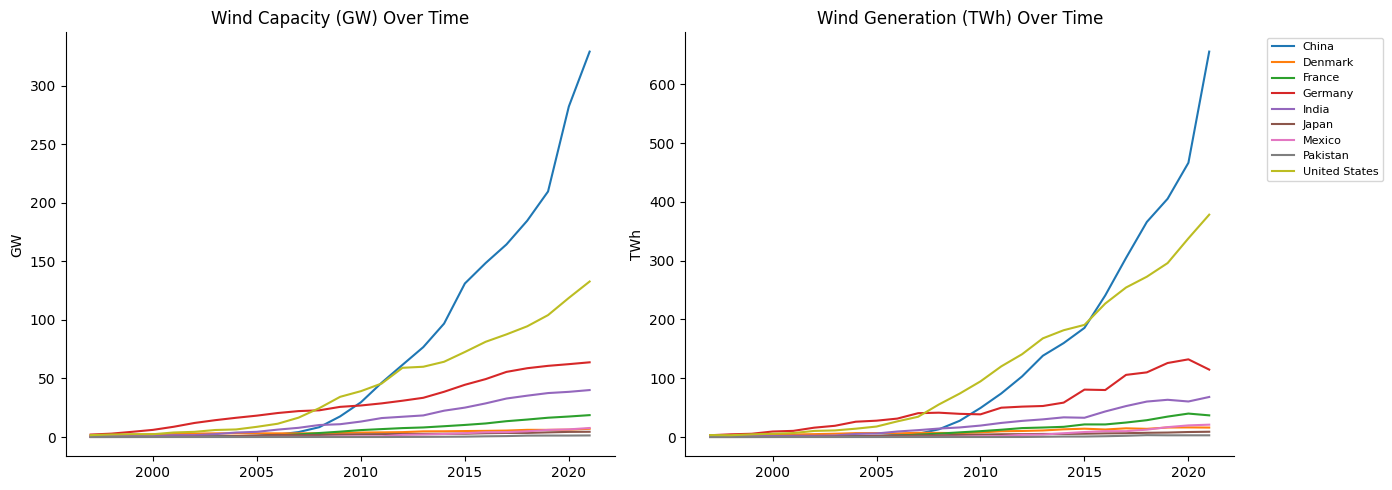

In [43]:
# Wind capacity (GW) and generation (TWh) over time, one line per country.
# Confirms capacity and generation track together and shows when each country
# began significant wind development.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country in df_cap['Entity'].unique():
    sub = df_cap[df_cap['Entity'] == country]
    axes[0].plot(sub['Year'], sub['wind_cap'], label=country)
    axes[1].plot(sub['Year'], sub['wind_gen'], label=country)

axes[0].set_title('Wind Capacity (GW) Over Time')
axes[0].set_ylabel('GW')
axes[1].set_title('Wind Generation (TWh) Over Time')
axes[1].set_ylabel('TWh')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

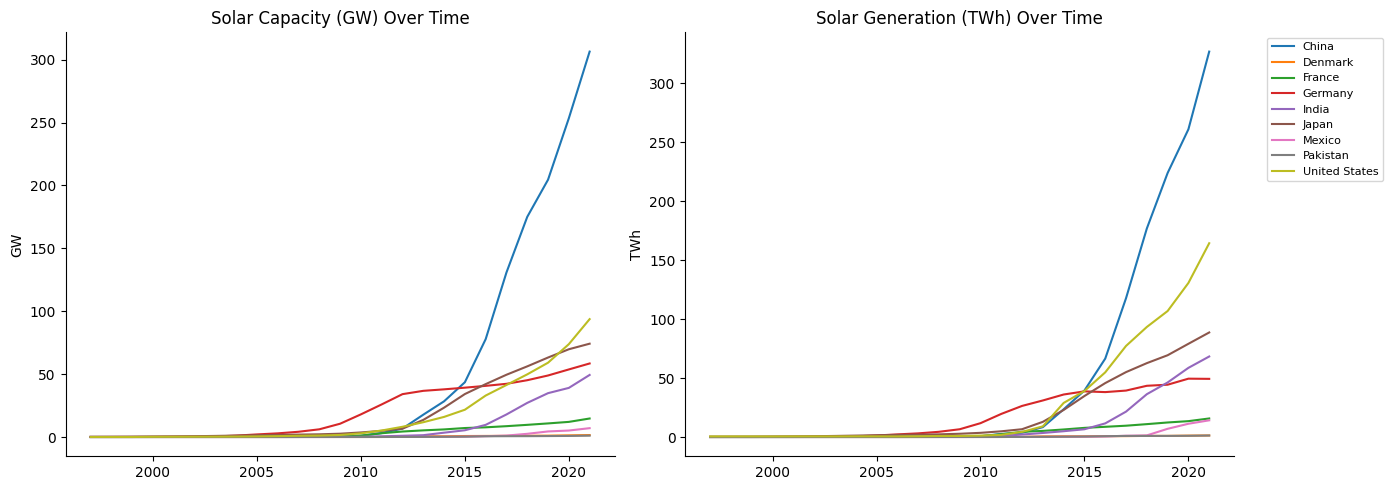

In [44]:
# Solar capacity (GW) and generation (TWh) over time, one line per country.
# Solar adoption started much later than wind (most countries post-2008),
# and China's buildout dominates after ~2013.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country in df_cap['Entity'].unique():
    sub = df_cap[df_cap['Entity'] == country]
    axes[0].plot(sub['Year'], sub['solar_cap'], label=country)
    axes[1].plot(sub['Year'], sub['solar_gen'], label=country)

axes[0].set_title('Solar Capacity (GW) Over Time')
axes[0].set_ylabel('GW')
axes[1].set_title('Solar Generation (TWh) Over Time')
axes[1].set_ylabel('TWh')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

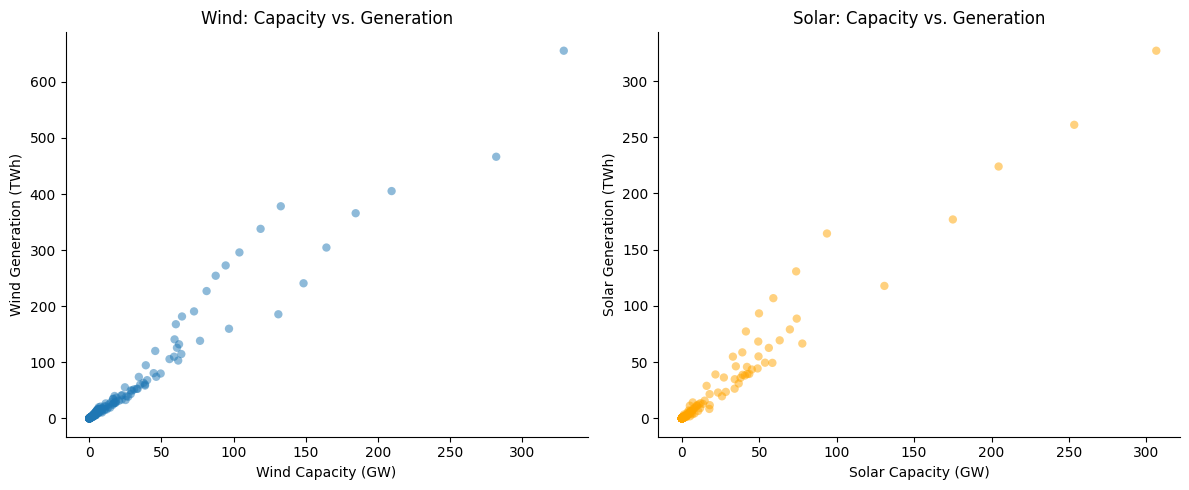

In [45]:
# Scatter of capacity vs. generation pooled across all countries and years.
# Confirms a positive relationship before modeling. Large countries (China, USA)
# will dominate the upper right — country fixed effects handle this in the regression.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_cap['wind_cap'], df_cap['wind_gen'], alpha=0.5, edgecolors='none')
axes[0].set_xlabel('Wind Capacity (GW)')
axes[0].set_ylabel('Wind Generation (TWh)')
axes[0].set_title('Wind: Capacity vs. Generation')

axes[1].scatter(df_cap['solar_cap'], df_cap['solar_gen'], alpha=0.5, color='orange', edgecolors='none')
axes[1].set_xlabel('Solar Capacity (GW)')
axes[1].set_ylabel('Solar Generation (TWh)')
axes[1].set_title('Solar: Capacity vs. Generation')

plt.tight_layout()
plt.show()

## 4. Regression 1: Capacity → Generation

**Model:**
$$\text{Generation}_{it} = \beta_1 \cdot \text{Capacity}_{it} + \alpha_i + \gamma_t + \varepsilon_{it}$$

Where $\alpha_i$ = country fixed effects and $\gamma_t$ = year fixed effects.

**Interpretation of $\beta_1$:** How many additional TWh of electricity are generated per additional GW of installed capacity, holding country-level differences and global year trends constant.

In [46]:
# Wind generation ~ wind capacity + country FE + year FE
#
# C(Entity) and C(Year) create dummy variables for each country and year,
# controlling for persistent country-level differences and global year trends.
# This means β1 is estimated from within-country variation only.
#
# cov_type='HC3' uses heteroskedasticity-robust standard errors since
# variance in generation differs greatly across small vs. large countries.
wind_gen_model = smf.ols(
    'wind_gen ~ wind_cap + C(Entity) + C(Year)',
    data=df_cap
).fit(cov_type='HC3')

print('=== WIND: Generation ~ Capacity + Country FE + Year FE ===')
print(f'N = {int(wind_gen_model.nobs)}')
print(f'R² = {wind_gen_model.rsquared:.4f}    Adj. R² = {wind_gen_model.rsquared_adj:.4f}')
print()

# Filter to show only the capacity coefficient — not all the FE dummy coefficients
key_vars = [v for v in wind_gen_model.params.index if 'cap' in v.lower()]
print(wind_gen_model.summary2().tables[1].loc[key_vars])

=== WIND: Generation ~ Capacity + Country FE + Year FE ===
N = 225
R² = 0.9715    Adj. R² = 0.9666

             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
wind_cap  1.953914  0.104564  18.686281  6.402293e-78  1.748972  2.158855


In [47]:
# Solar generation ~ solar capacity + country FE + year FE
#
# Run separately from wind rather than combined to avoid multicollinearity
# (countries that build wind also tend to build solar). Gives a clean estimate
# of solar's own capacity-to-generation relationship.
solar_gen_model = smf.ols(
    'solar_gen ~ solar_cap + C(Entity) + C(Year)',
    data=df_cap
).fit(cov_type='HC3')

print('=== SOLAR: Generation ~ Capacity + Country FE + Year FE ===')
print(f'N = {int(solar_gen_model.nobs)}')
print(f'R² = {solar_gen_model.rsquared:.4f}    Adj. R² = {solar_gen_model.rsquared_adj:.4f}')
print()

key_vars = [v for v in solar_gen_model.params.index if 'cap' in v.lower()]
print(solar_gen_model.summary2().tables[1].loc[key_vars])

=== SOLAR: Generation ~ Capacity + Country FE + Year FE ===
N = 225
R² = 0.9732    Adj. R² = 0.9685

              Coef.  Std.Err.         z  P>|z|    [0.025    0.975]
solar_cap  1.060101  0.025527  41.52879    0.0  1.010069  1.110133


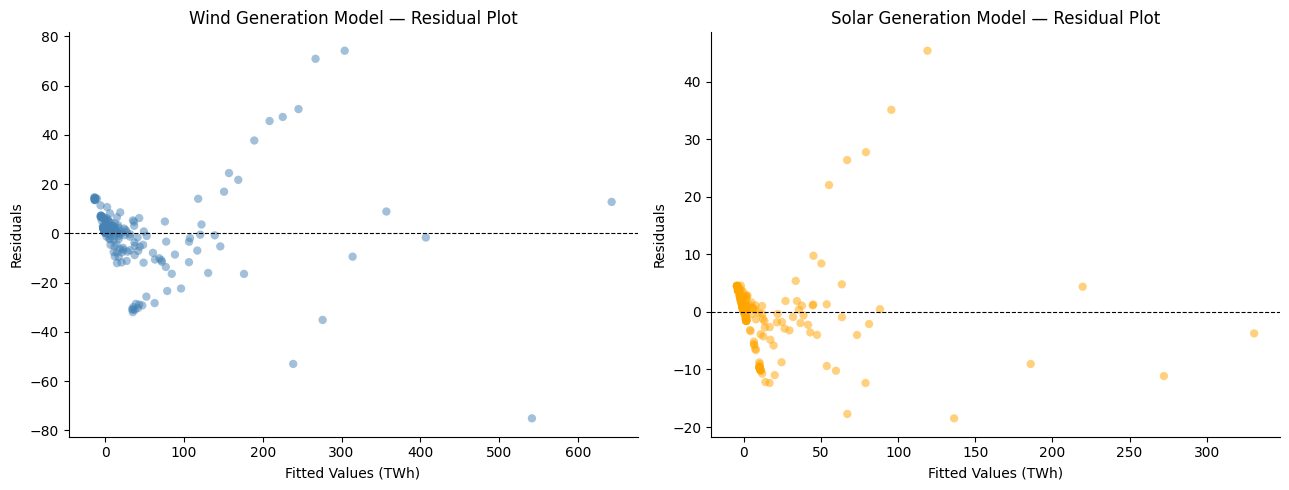

In [48]:
# Residual plots (fitted values vs. residuals) for both generation models.
# Residuals should be randomly scattered around zero — a fan shape would indicate
# heteroskedasticity, and a curve would suggest a non-linear relationship.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, label, color in zip(
    axes,
    [wind_gen_model, solar_gen_model],
    ['Wind', 'Solar'],
    ['steelblue', 'orange']
):
    ax.scatter(model.fittedvalues, model.resid, alpha=0.5, color=color, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Fitted Values (TWh)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{label} Generation Model — Residual Plot')

plt.tight_layout()
plt.show()

## 5. Regression 3: Capacity → Renewable Electricity Share

**Model:**
$$\text{Renewables\%}_{it} = \beta_1 \cdot \text{WindCap}_{it} + \beta_2 \cdot \text{SolarCap}_{it} + \alpha_i + \gamma_t + \varepsilon_{it}$$

**Interpretation:** How many additional percentage points of electricity share come from each additional GW of wind or solar capacity, controlling for country differences and year trends.

This is a more policy-relevant question — does building capacity actually shift the energy mix?

In [49]:
# Renewable electricity share ~ wind capacity + solar capacity + country FE + year FE
#
# More policy-relevant than Regression 1: asks whether building capacity actually
# shifts the energy mix, not just whether capacity produces electricity.
# Including both wind_cap and solar_cap together lets us estimate each technology's
# marginal contribution to share while holding the other constant.
df_share = df_cap.dropna(subset=['renew_share_elec']).copy()
print(f'N for share regression: {len(df_share)}')

share_model = smf.ols(
    'renew_share_elec ~ wind_cap + solar_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

print()
print('=== Renewables (% electricity) ~ Wind Cap + Solar Cap + Country FE + Year FE ===')
print(f'N = {int(share_model.nobs)}')
print(f'R² = {share_model.rsquared:.4f}    Adj. R² = {share_model.rsquared_adj:.4f}')
print()

key_vars = [v for v in share_model.params.index if 'cap' in v.lower()]
print(share_model.summary2().tables[1].loc[key_vars])

N for share regression: 225

=== Renewables (% electricity) ~ Wind Cap + Solar Cap + Country FE + Year FE ===
N = 225
R² = 0.6510    Adj. R² = 0.5886

              Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
wind_cap  -0.015929  0.021891 -0.727637  0.466836 -0.058835  0.026977
solar_cap -0.004067  0.036115 -0.112618  0.910334 -0.074852  0.066717


In [50]:
# Wind-only and solar-only versions of the share regression as a robustness check.
# If coefficients are larger here than in the joint model, it suggests wind and solar
# capacity are correlated and the joint model is splitting the shared effect between them.
wind_share_model = smf.ols(
    'renew_share_elec ~ wind_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

solar_share_model = smf.ols(
    'renew_share_elec ~ solar_cap + C(Entity) + C(Year)',
    data=df_share
).fit(cov_type='HC3')

print('=== Wind Capacity Only ===')
key = [v for v in wind_share_model.params.index if 'cap' in v.lower()]
print(wind_share_model.summary2().tables[1].loc[key])

print()
print('=== Solar Capacity Only ===')
key = [v for v in solar_share_model.params.index if 'cap' in v.lower()]
print(solar_share_model.summary2().tables[1].loc[key])

=== Wind Capacity Only ===
             Coef.  Std.Err.         z    P>|z|    [0.025    0.975]
wind_cap -0.019203   0.01635 -1.174511  0.24019 -0.051248  0.012842

=== Solar Capacity Only ===
              Coef.  Std.Err.         z     P>|z|   [0.025    0.975]
solar_cap -0.019982  0.021775 -0.917672  0.358791 -0.06266  0.022696


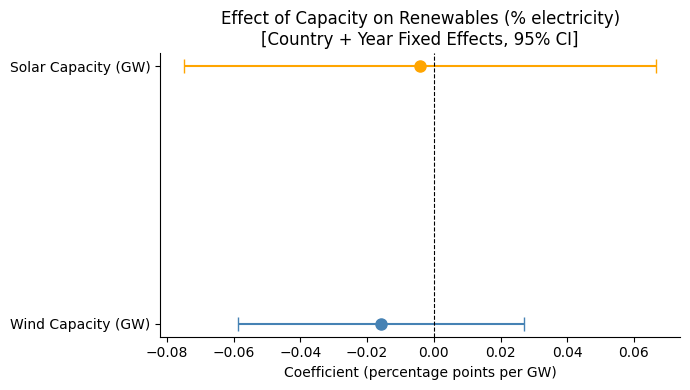

In [51]:
# Coefficient plot for the joint share model with 95% confidence intervals.
# Dots are point estimates; bars are the CI. If a bar does not cross the dashed
# zero line, the effect is statistically significant at the 5% level.
coef_names  = ['wind_cap', 'solar_cap']
coefs       = share_model.params[coef_names]
conf        = share_model.conf_int().loc[coef_names]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue', 'orange']
for i, (name, color) in enumerate(zip(coef_names, colors)):
    ax.errorbar(
        x=coefs[name],
        y=i,
        xerr=[[coefs[name] - conf.loc[name, 0]], [conf.loc[name, 1] - coefs[name]]],
        fmt='o', color=color, capsize=5, markersize=8
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Wind Capacity (GW)', 'Solar Capacity (GW)'])
ax.set_xlabel('Coefficient (percentage points per GW)')
ax.set_title('Effect of Capacity on Renewables (% electricity)\n[Country + Year Fixed Effects, 95% CI]')
plt.tight_layout()
plt.show()

## 6. Summary Table

Quick comparison of key coefficients across all four models.

In [52]:
# Pulls the key coefficient, standard error, p-value, R², and N from each model
# into one comparison table. p-value column is 'P>|z|' (not 'P>|t|') because
# HC3 robust standard errors produce z-statistics instead of t-statistics.
def extract_row(model, var, label):
    t = model.summary2().tables[1]
    row = t.loc[var]
    p_col = "P>|z|" if "P>|z|" in row.index else "P>|t|"
    return {
        "Model": label,
        "Coefficient": round(row["Coef."], 4),
        "Std Error": round(row["Std.Err."], 4),
        "p-value": round(row[p_col], 4),
        "R²": round(model.rsquared, 4),
        "N": int(model.nobs)
    }

summary = pd.DataFrame([
    extract_row(wind_gen_model,   "wind_cap",  "Wind Generation ~ Wind Cap"),
    extract_row(solar_gen_model,  "solar_cap", "Solar Generation ~ Solar Cap"),
    extract_row(share_model,      "wind_cap",  "Renewables % ~ Wind Cap + Solar Cap (wind)"),
    extract_row(share_model,      "solar_cap", "Renewables % ~ Wind Cap + Solar Cap (solar)"),
])

summary

,Model,Coefficient,Std Error,p-value,R²,N
0,Wind Generation ~ Wind Cap,1.9539,0.1046,0.0000,0.9715,225
1,Solar Generation ~ Solar Cap,1.0601,0.0255,0.0000,0.9732,225
2,Renewables % ~ Wind Cap + Solar Cap (wind),-0.0159,0.0219,0.4668,0.6510,225
3,Renewables % ~ Wind Cap + Solar Cap (solar),-0.0041,0.0361,0.9103,0.6510,225


## 7. Notes and Next Steps

**Limitations of these baseline models:**
- Only 9 countries with capacity data — limits generalizability
- No lagged variables — capacity built today generates electricity next year, not instantly
- Capacity and generation are mechanically related (more capacity → more generation by definition), so the regression 1 coefficients largely capture a physical relationship rather than a behavioral one

**Suggested extensions:**
- Add **lagged capacity** (1–3 year lag) to better capture the deployment-to-generation timeline
- Separate regressions **per country** to see if the capacity-generation relationship differs (e.g., China vs. Denmark)
- Use the broader `merged_renewables_data.csv` (251 countries) for regression 3 using lagged generation as a proxy for capacity
- Interaction terms: does wind capacity have a different effect on share in high-hydro vs. low-hydro countries?

## 8. Growth Decomposition

For each country, measure the total change in renewable electricity share from the first to last available year, then split that change into wind, solar, hydro, and residual "other" components.

**Interpretation:** Which technology drove the rise (or fall) in renewable share in each country?

In [53]:
import numpy as np

decomp_rows = []
for country, sub in df_cap.groupby('Entity'):
    sub = sub.dropna(subset=['renew_share_elec','wind_share_elec','solar_share_elec','hydro_share_elec']).sort_values('Year')
    if len(sub) < 2:
        continue
    first, last = sub.iloc[0], sub.iloc[-1]
    d_total = float(last['renew_share_elec'] - first['renew_share_elec'])
    d_wind  = float(last['wind_share_elec']  - first['wind_share_elec'])
    d_solar = float(last['solar_share_elec'] - first['solar_share_elec'])
    d_hydro = float(last['hydro_share_elec'] - first['hydro_share_elec'])
    d_other = d_total - (d_wind + d_solar + d_hydro)
    decomp_rows.append({'Entity': country,
                        'start_year': int(first['Year']), 'end_year': int(last['Year']),
                        'total_pp': round(d_total,2),
                        'wind_pp':  round(d_wind,2),
                        'solar_pp': round(d_solar,2),
                        'hydro_pp': round(d_hydro,2),
                        'other_pp': round(d_other,2)})

decomp = pd.DataFrame(decomp_rows).sort_values('total_pp', ascending=False).reset_index(drop=True)
decomp

,Entity,start_year,end_year,total_pp,wind_pp,solar_pp,hydro_pp,other_pp
0,Denmark,1997,2021,72.33,44.19,3.96,0.02,24.16
1,Germany,1997,2021,35.43,19.14,8.47,0.21,7.61
2,Japan,1997,2021,12.85,0.93,9.24,0.06,2.61
3,China,1997,2021,11.39,7.71,3.85,-1.94,1.76
4,United States,1997,2021,9.30,9.02,3.95,-3.64,-0.03
5,France,1997,2021,8.97,6.69,2.86,-1.90,1.32
6,Mexico,1997,2021,4.59,6.22,4.20,-5.58,-0.25
7,India,1997,2021,4.00,3.76,3.98,-5.61,1.86
8,Pakistan,1997,2021,0.22,1.92,0.84,-3.55,1.01


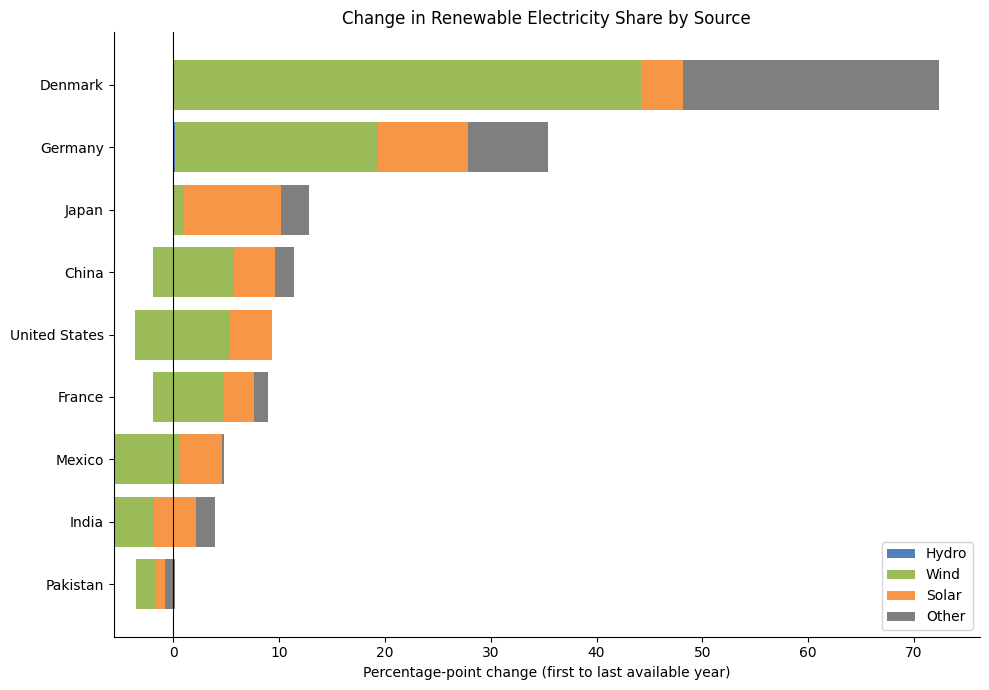

In [54]:
plot_df = decomp.sort_values('total_pp')
fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(plot_df))
for col, color, label in [
    ('hydro_pp', '#4f81bd', 'Hydro'),
    ('wind_pp',  '#9bbb59', 'Wind'),
    ('solar_pp', '#f79646', 'Solar'),
    ('other_pp', '#7f7f7f', 'Other'),
]:
    vals = plot_df[col].to_numpy()
    ax.barh(plot_df['Entity'], vals, left=left, color=color, label=label)
    left = left + vals
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Change in Renewable Electricity Share by Source')
ax.set_xlabel('Percentage-point change (first to last available year)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Lagged Capacity Models

Re-run the three regressions (wind generation, solar generation, renewable share) at lags 0–3.

**Motivation:** Capacity installed today generates electricity next year, not instantly. A 1–3 year lag tests whether the capacity-to-outcome relationship is stronger once the infrastructure is fully online.

**Model (lag $k$):**
$$\text{Outcome}_{it} = \beta \cdot \text{Capacity}_{i,t-k} + \alpha_i + \gamma_t + \varepsilon_{it}$$

In [55]:
def add_lags(df, max_lag=3):
    out = df.copy()
    for lag in range(1, max_lag + 1):
        out[f'wind_cap_lag{lag}']  = out.groupby('Entity')['wind_cap'].shift(lag)
        out[f'solar_cap_lag{lag}'] = out.groupby('Entity')['solar_cap'].shift(lag)
    return out

panel = add_lags(df_cap)

specs = [
    ('wind_gen',        'wind',  'Wind Generation (TWh)'),
    ('solar_gen',       'solar', 'Solar Generation (TWh)'),
    ('renew_share_elec','both',  'Renewables % Electricity'),
]

lag_rows = []
for outcome, ptype, label in specs:
    for lag in range(0, 4):
        wind_rhs  = 'wind_cap'  if lag == 0 else f'wind_cap_lag{lag}'
        solar_rhs = 'solar_cap' if lag == 0 else f'solar_cap_lag{lag}'
        if ptype == 'wind':
            formula = f'{outcome} ~ {wind_rhs} + C(Entity) + C(Year)'
            coef_names = [wind_rhs]
        elif ptype == 'solar':
            formula = f'{outcome} ~ {solar_rhs} + C(Entity) + C(Year)'
            coef_names = [solar_rhs]
        else:
            formula = f'{outcome} ~ {wind_rhs} + {solar_rhs} + C(Entity) + C(Year)'
            coef_names = [wind_rhs, solar_rhs]
        needed = list({outcome} | set(coef_names))
        reg_df = panel.dropna(subset=needed)
        if len(reg_df) == 0:
            continue
        model = smf.ols(formula, data=reg_df).fit(cov_type='HC3')
        tbl = model.summary2().tables[1]
        for cn in coef_names:
            row = tbl.loc[cn]
            pcol = 'P>|z|' if 'P>|z|' in row.index else 'P>|t|'
            lag_rows.append({'outcome_label': label, 'outcome': outcome,
                             'lag': lag, 'predictor': cn,
                             'coef': round(float(row['Coef.']),4),
                             'std_err': round(float(row['Std.Err.']),4),
                             'p_value': round(float(row[pcol]),4),
                             'r_squared': round(float(model.rsquared),4),
                             'n': int(model.nobs)})

lag_results = pd.DataFrame(lag_rows)
print(lag_results.to_string(index=False))

           outcome_label          outcome  lag      predictor    coef  std_err  p_value  r_squared   n
   Wind Generation (TWh)         wind_gen    0       wind_cap  1.9539   0.1046   0.0000     0.9715 225
   Wind Generation (TWh)         wind_gen    1  wind_cap_lag1  2.3233   0.0571   0.0000     0.9801 216
   Wind Generation (TWh)         wind_gen    2  wind_cap_lag2  2.7511   0.1742   0.0000     0.9768 207
   Wind Generation (TWh)         wind_gen    3  wind_cap_lag3  3.0897   0.2098   0.0000     0.9755 198
  Solar Generation (TWh)        solar_gen    0      solar_cap  1.0601   0.0255   0.0000     0.9732 225
  Solar Generation (TWh)        solar_gen    1 solar_cap_lag1  1.2965   0.0359   0.0000     0.9699 216
  Solar Generation (TWh)        solar_gen    2 solar_cap_lag2  1.5815   0.0763   0.0000     0.9490 207
  Solar Generation (TWh)        solar_gen    3 solar_cap_lag3  1.9069   0.1555   0.0000     0.9088 198
Renewables % Electricity renew_share_elec    0       wind_cap -0.0159   0

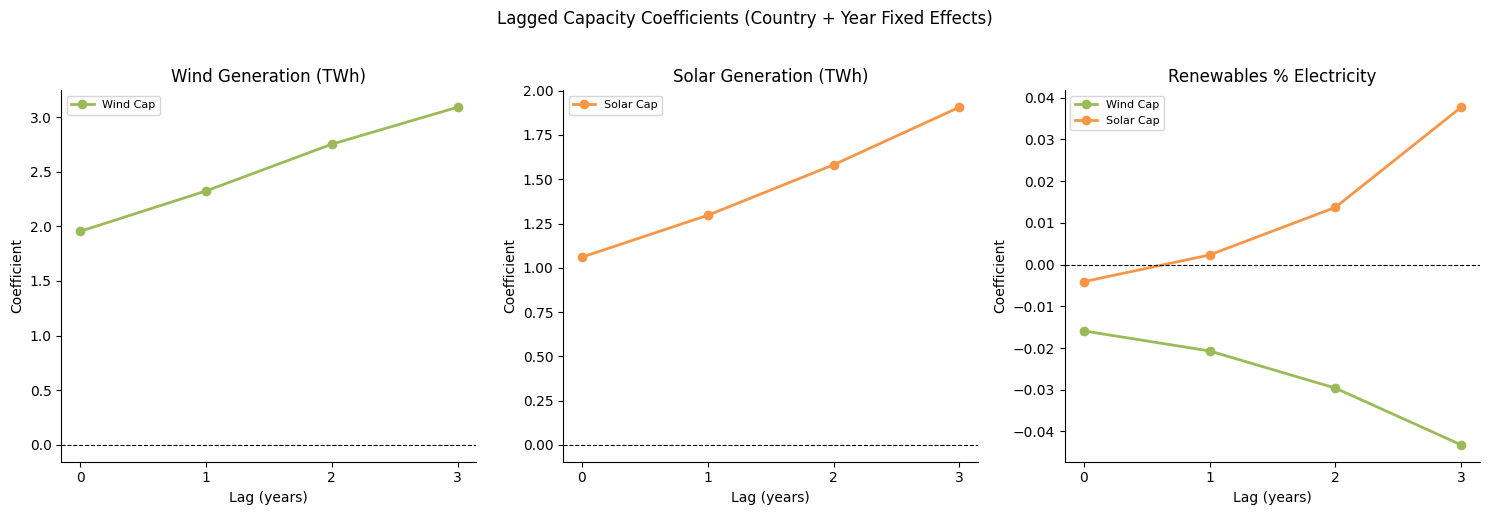

In [56]:
# Coefficient plots: one panel per outcome, coefficient vs. lag year.
# Group by base technology (wind/solar) so all 4 lags form a single connected line.
outcomes = lag_results['outcome'].unique()
fig, axes = plt.subplots(1, len(outcomes), figsize=(15, 5))

for ax, outcome in zip(axes, outcomes):
    sub = lag_results[lag_results['outcome'] == outcome]
    for base, color, label in [('wind', '#9bbb59', 'Wind Cap'), ('solar', '#f79646', 'Solar Cap')]:
        psub = sub[sub['predictor'].str.contains(base)].sort_values('lag')
        if psub.empty:
            continue
        ax.plot(psub['lag'], psub['coef'], marker='o', linewidth=2, color=color, label=label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks([0,1,2,3])
    ax.set_xlabel('Lag (years)')
    ax.set_ylabel('Coefficient')
    ax.set_title(sub['outcome_label'].iloc[0])
    ax.legend(fontsize=8)

plt.suptitle('Lagged Capacity Coefficients (Country + Year Fixed Effects)', y=1.02)
plt.tight_layout()
plt.show()


## 10. Lagged Model Summary Table

In [57]:
lag_results[['outcome_label','lag','predictor','coef','std_err','p_value','r_squared','n']].rename(columns={'outcome_label':'Outcome','lag':'Lag','predictor':'Predictor',
                  'coef':'Coef','std_err':'Std Err','p_value':'p-value',
                  'r_squared':'R²','n':'N'})

,Outcome,Lag,Predictor,Coef,Std Err,p-value,R²,N
0,Wind Generation (TWh),0,wind_cap,1.9539,0.1046,0.0000,0.9715,225
1,Wind Generation (TWh),1,wind_cap_lag1,2.3233,0.0571,0.0000,0.9801,216
2,Wind Generation (TWh),2,wind_cap_lag2,2.7511,0.1742,0.0000,0.9768,207
3,Wind Generation (TWh),3,wind_cap_lag3,3.0897,0.2098,0.0000,0.9755,198
4,Solar Generation (TWh),0,solar_cap,1.0601,0.0255,0.0000,0.9732,225
5,Solar Generation (TWh),1,solar_cap_lag1,1.2965,0.0359,0.0000,0.9699,216
6,Solar Generation (TWh),2,solar_cap_lag2,1.5815,0.0763,0.0000,0.9490,207
7,Solar Generation (TWh),3,solar_cap_lag3,1.9069,0.1555,0.0000,0.9088,198
8,Renewables % Electricity,0,wind_cap,-0.0159,0.0219,0.4668,0.6510,225
9,Renewables % Electricity,0,solar_cap,-0.0041,0.0361,0.9103,0.6510,225
